# <font size="7"> **Assignment-6**</font>
I hope this assignment will give you clarity on how mathematical models like **Multilayer Perceptrons (MLP)** can be made from scratch using **PyTorch** & can be used to solve complex, non-linear geometric problems **without relying on black-box libraries**.

---
# ⚫ **Mission Critical: The Exclusion Zone Protocol**

**Date:** Year 2142  
**Location:** Exoplanet *Kepler-186f*   **Clearance:** IITians

---

### **⚫ The Story**
Humanity has colonized the distant exoplanet *Kepler-186f*. While the surface is habitable, the planet's magnetic core is unstable. The **Global Defense Council (GDC)** has identified a dangerous phenomenon known as the **"Radiation Ring."**

Sensors indicate that the safe zones on the planet follow a peculiar geometry:
* ⚫ **The Core Zone:** Distance $< 2$ km from the colony center (Safe).
* ⚫ **The Outer Wilds:** Distance $> 4$ km from the colony center (Safe).
* ⚫ **The Dead Zone:** The region **between 2 km and 4 km** is flooded with lethal gamma radiation.

Your engineering team has deployed **3,000 sensor drones** across the colony to map this danger. Each drone reports its coordinates $(x, y)$ and a binary label:
* `1`: Radiation Detected (Dead Zone)
* `0`: Safe Zone

 **⚫ The Problem:** The sensors are cheap and prone to interference. Approximately **5%** of the drones are malfunctioning and reporting the wrong safety status (noise). The GDC mainframe is a legacy system that forbids the use of modern "Neural Libraries" (i.e., you cannot use `torch.nn` or `torch.optim`). You must build a **Multi-Layer Perceptron (MLP) from scratch** to filter out the noise and mathematically define the Exclusion Zone boundaries using **PyTorch**. ( Hint: You know this is a binary classification problem, which Loss function would you use?? )

---

### **⚫ Your Objective**

1.  **Initialize the System:** Use your **Group Number** as the random seed. This ensures your team works on a unique sensor distribution pattern.
2.  **Architect the Filter:** Construct a neural network with **3 hidden layers** (16 neurons each) to learn the non-linear "donut" shape of the Dead Zone.
3.  **Manual Calibration:** You cannot use auto-optimizers. You must manually calculate the gradients (Backpropagation) and update the system weights using **Gradient Descent**.
4.  **Verify Integrity:** Split your sensor data (70% training, 30% validation). Prove that your system doesn't just memorize the malfunctioning sensors (overfitting) but actually learns the geometric shape of the Dead Zone.

---

## ⚫ Engineering Constraints (Read Carefully)

**1. Restricted Modules**
*  **Forbidden:** You are strictly forbidden from importing `torch.nn` (Layers/Loss) or `torch.optim` (Optimizers).
*  **Allowed:** `import torch`, `import matplotlib.pyplot`, `import pandas`, `import numpy`, using `sklearn`.


**2. The Mechanics**
* **Forward Pass:** Must be implemented using raw matrix multiplication (`torch.matmul`) and bias addition.
* **Backward Pass:** You **MAY** use `loss.backward()` to compute gradients automatically (Autograd).
* **Optimization:** You **MUST** implement the weight updates manually (Stochastic Gradient Descent).
    > `w_new = w_old - learning_rate * w_old.grad`

**3. Loss Function**
Since `torch.nn` is banned, you must implement **Binary Cross Entropy** manually using basic tensor math.

$$Loss = -\frac{1}{N} \sum_{i=1}^{N} [y_i \cdot \log(\hat{y}_i) + (1-y_i) \cdot \log(1-\hat{y}_i)]$$

* **Note:** Ensure you handle the log of zero (numerical stability) or use `torch.clamp` to avoid `NaN` errors.

**4. Visual Proof:** Your final output must include a Decision Boundary Map showing the "Donut" shape.


---

### ⚫ **The GDC Dashboard (Required Output)**



The Global Defense Council requires visual confirmation that your system is stable before we can upload it to the drone fleet. You must generate a **3-Panel Heads-Up Display (HUD)** containing the following telemetry:

**1. System Error Trajectory (Loss Plot)**
* **Mission:** Plot the **Training Loss** (Blue) vs. **Validation Loss** (Orange) over all epochs.
* **Why:** We need to confirm that the system is actually learning and not just diverging (exploding gradients).

**2. Integrity Check (Accuracy Plot)**
* **Mission:** Plot the **Training Accuracy** vs. **Validation Accuracy**.
* **Why:** If Training Accuracy is high (95%) but Validation Accuracy is low (80%), you have failed to generalize. This is a sign of **Overfitting**—memorizing sensor noise instead of the Radiation Ring.

**3. Geospatial Threat Map (Decision Boundary)**
* **Mission:** Visualize the **Validation Set** on a 2D map.
* **Overlay:** Draw the neural network's **Decision Boundary** (the contours where confidence = 0.5).
* **Why:** The Commander needs to *see* the "Donut" shape. If your boundary looks like a jagged mess, the model is rejected.

---

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
# ===========================================================
# PART 1: Data Generation (The Exclusion Zone)
# ===========================================================

# ⚠️ INSTRUCTION: Replace 1 with your actual Group Number
GROUP_NUMBER = 10

# Set seed for reproducibility
torch.manual_seed(GROUP_NUMBER)
np.random.seed(GROUP_NUMBER)

def generate_data(n_samples=3000):
    """
    Generates 3000 sensor readings for the Kepler-186f Exclusion Zone.
    Shape: Concentric circles (Donut).
    Logic:
      - Dead Zone (1): 2km < distance < 4km
      - Safe Zone (0): distance < 2km OR distance > 4km
    """
    # Generate random coordinates between -5 and 5 km
    X = (torch.rand(n_samples, 2) * 10) - 5

    # Calculate distance from center (radius)
    radius = torch.sqrt(X[:, 0]**2 + X[:, 1]**2)

    # Assign Labels: 1 if inside the Dead Zone, 0 otherwise
    y = ((radius > 2) & (radius < 4)).float().view(-1, 1)

    # Add 5% Noise (Malfunctioning Drones)
    n_noise = int(0.05 * n_samples)
    noise_indices = torch.randperm(n_samples)[:n_noise]
    y[noise_indices] = 1 - y[noise_indices] # Flip labels

    return X, y

# Generate the dataset
X_full, y_full = generate_data(3000)

print(f"Data Generated: {X_full.shape} samples.")
print(f"Target Generated: {y_full.shape} labels.")

Data Generated: torch.Size([3000, 2]) samples.
Target Generated: torch.Size([3000, 1]) labels.


Epoch 0 | Loss: 0.7075 | Val Acc: 0.5333


/tmp/ipython-input-3570469620.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train=torch.tensor(X_train,requires_grad=True)
/tmp/ipython-input-3570469620.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train=torch.tensor(y_train,requires_grad=True)
/tmp/ipython-input-3570469620.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_val=torch.tensor(X_val)
/tmp/ipython-input-3570469620.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requ

Epoch 100 | Loss: 0.6032 | Val Acc: 0.5550
Epoch 200 | Loss: 0.5274 | Val Acc: 0.7300
Epoch 300 | Loss: 0.4784 | Val Acc: 0.7750
Epoch 400 | Loss: 0.4436 | Val Acc: 0.8083
Epoch 500 | Loss: 0.4165 | Val Acc: 0.8067
Epoch 600 | Loss: 0.4044 | Val Acc: 0.8617
Epoch 700 | Loss: 0.3812 | Val Acc: 0.8950
Epoch 800 | Loss: 0.3609 | Val Acc: 0.9050
Epoch 900 | Loss: 0.3502 | Val Acc: 0.9000
Epoch 1000 | Loss: 0.3381 | Val Acc: 0.9067
Epoch 1100 | Loss: 0.3326 | Val Acc: 0.9100
Epoch 1200 | Loss: 0.3268 | Val Acc: 0.9150
Epoch 1300 | Loss: 0.3230 | Val Acc: 0.9133
Epoch 1400 | Loss: 0.3197 | Val Acc: 0.9167
Epoch 1500 | Loss: 0.3163 | Val Acc: 0.9200
Epoch 1600 | Loss: 0.3131 | Val Acc: 0.9217
Epoch 1700 | Loss: 0.3053 | Val Acc: 0.9283
Epoch 1800 | Loss: 0.3096 | Val Acc: 0.9217
Epoch 1900 | Loss: 0.3059 | Val Acc: 0.9217


/tmp/ipython-input-3570469620.py:81: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),np.arange(y_min, y_max, 0.1))


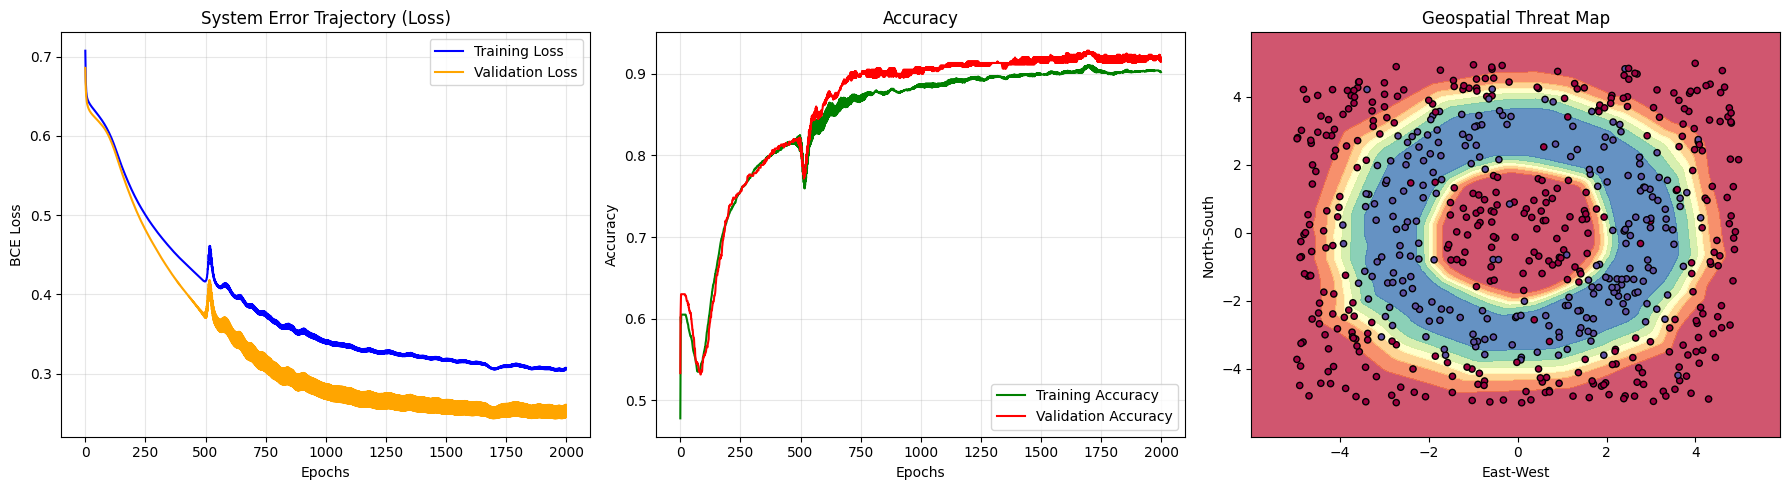

In [2]:
# ==============================================================================
# Code from here. Best of luckk :)
# ==============================================================================
X_train, y_train = X_full[:2400], y_full[:2400]
X_val, y_val = X_full[2400:], y_full[2400:]
X_train=torch.tensor(X_train,requires_grad=True)
y_train=torch.tensor(y_train,requires_grad=True)
X_val=torch.tensor(X_val)
y_val=torch.tensor(y_val)
def init_weights(input_size, output_size):
    std = np.sqrt(2.0 / (input_size + output_size))
    w = torch.randn(input_size, output_size) * std
    b = torch.zeros(1, output_size)
    w.requires_grad = True
    b.requires_grad = True
    return w, b
W1, b1 = init_weights(2, 16)
W2, b2 = init_weights(16, 16)
W3, b3 = init_weights(16, 16)
W4, b4 = init_weights(16, 1)
def relu(x):
    return torch.maximum(x, torch.tensor(0.0))
def sigmoid(x):
    return 1.0 / (1.0 + torch.exp(-x))
def forward_pass(x):
    z1 = torch.matmul(x, W1) + b1
    a1 = relu(z1)
    z2 = torch.matmul(a1, W2) + b2
    a2 = relu(z2)
    z3 = torch.matmul(a2, W3) + b3
    a3 = relu(z3)
    z4 = torch.matmul(a3, W4) + b4
    a4 = sigmoid(z4)
    return a4
def manual_bce_loss(y_pred, y_true):
    y_pred = torch.clamp(y_pred, 1e-7, 1)
    loss = -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
    return torch.mean(loss)
parameters = [W1, b1, W2, b2, W3, b3, W4, b4]
epochs = 2000
learning_rate = 0.1
train_losses, val_losses = [], []
train_accs, val_accs = [], []
for epoch in range(epochs):
    y_pred_train = forward_pass(X_train)
    loss_train = manual_bce_loss(y_pred_train, y_train)
    loss_train.backward()
    with torch.no_grad():
        for p in parameters:
            p -= learning_rate * p.grad
            p.grad.zero_()
    with torch.no_grad():
        y_pred_val = forward_pass(X_val)
        loss_val = manual_bce_loss(y_pred_val, y_val)
        acc_train = ((y_pred_train > 0.5).float() == y_train).float().mean()
        acc_val = ((y_pred_val > 0.5).float() == y_val).float().mean()
    train_losses.append(loss_train.item())
    val_losses.append(loss_val.item())
    train_accs.append(acc_train.item())
    val_accs.append(acc_val.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss_train.item():.4f} | Val Acc: {acc_val.item():.4f}")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(train_losses, label='Training Loss', color='blue')
axes[0].plot(val_losses, label='Validation Loss', color='orange')
axes[0].set_title("Loss")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(train_accs, label='Training Accuracy', color='green')
axes[1].plot(val_accs, label='Validation Accuracy', color='red')
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
x_min, x_max = X_full[:, 0].min() - 1, X_full[:, 0].max() + 1
y_min, y_max = X_full[:, 1].min() - 1, X_full[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),np.arange(y_min, y_max, 0.1))
grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    Z = forward_pass(grid_tensor).reshape(xx.shape)
axes[2].contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Spectral) # The Heatmap
axes[2].scatter(X_val[:, 0], X_val[:, 1], c=y_val, edgecolors='k', marker='o', s=20, cmap=plt.cm.Spectral)
axes[2].set_title("Geospatial Threat Map")
axes[2].set_xlabel("East-West")
axes[2].set_ylabel("North-South")
plt.tight_layout()
plt.show()
